# Final Project NLP

Mateo Galvis L

## 1. Packages

In [1]:
# Basic imports
import pandas as pd
import matplotlib.pyplot as plt
# For text processing and metrics
import re
from sklearn.metrics.pairwise import cosine_similarity

# Model
from sentence_transformers import SentenceTransformer

In [2]:
from google.colab import drive
# Contect to your drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Read data

In [3]:
#df_news_AI = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news_AI = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/df_news_AI.parquet', engine='pyarrow')

In [4]:
display(df_news_AI.head(10))

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...
5,https://citylife.capetown/lb/uncategorized/how...,2023-12-12,en,Google Releases New Chatbot Bard as a Strong C...,Google Releases New Chatbot Bard as a Strong ...
6,https://citylife.capetown/technology/zoom-laun...,2023-09-07,en,Zoom Expands AI Offering with AI Companion and...,Zoom Expands AI Offering with AI Companion an...
7,https://citylife.capetown/uncategorized/pro-ai...,2023-08-04,en,Pro-AI Thinking: Enhancing Industrial Environm...,\n\nPro-AI Thinking: Enhancing Industrial Envi...
8,https://clickup.com/ai/prompts/business-risk-m...,2024-03-13,en,Best AI Prompts for Business Risk Management,Best AI Prompts for Business Risk ManagementPr...
9,https://crooksandliars.com/2025/12/state-ags-w...,2025-12-15,en,State AGs Warn AI Companies: Clean Up Your Chi...,\nState AGs Warn AI Companies: Clean Up Your C...


In [5]:
print('Initial dataframe shape :', df_news_AI.shape)
print('Columns in the dataframe :', df_news_AI.columns)

Initial dataframe shape : (199989, 5)
Columns in the dataframe : Index(['url', 'date', 'language', 'title', 'text'], dtype='object')


In [6]:
display(df_news_AI.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 7.6+ MB


None

Not null values

In [7]:
# Transform the date column to datetime format
df_news_AI['date'] = pd.to_datetime(df_news_AI['date'])

In [8]:
# Obtain year and month from the date column
df_news_AI['year'] = df_news_AI['date'].dt.year
df_news_AI['month'] = df_news_AI['date'].dt.month

In [9]:
display(df_news_AI.head())

,url,date,language,title,text,year,month
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,2023,11
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,2023,11


Total number of articles: 199989


,year,article_count,%article_count
0,2022,18361,9.0
1,2023,71383,36.0
2,2024,49789,25.0
3,2025,54345,27.0
4,2026,6111,3.0


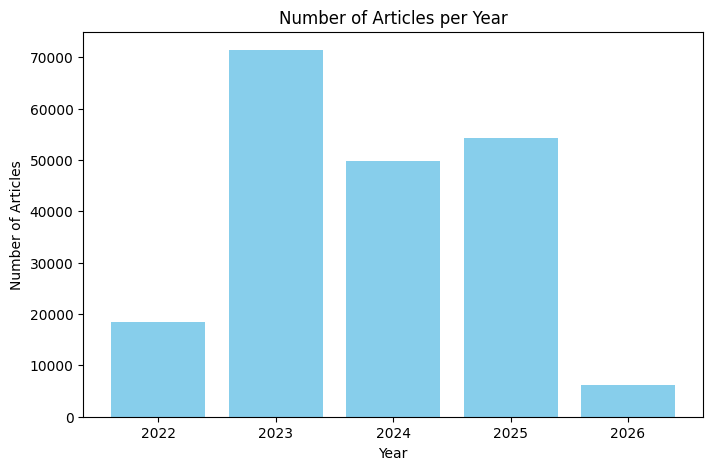

In [10]:
# Check the total number of articles per year
df_aux = df_news_AI.groupby('year')[['url']].count().reset_index()
df_aux = df_aux.rename(columns={'url': 'article_count'})
total_articles = df_aux['article_count'].sum()
df_aux['%article_count'] = round(df_aux['article_count'] / total_articles,2) * 100
print('Total number of articles:', total_articles)
display(df_aux)


# Create plot of article count per year
plt.figure(figsize=(8, 5))
plt.bar(df_aux['year'], df_aux['article_count'], color='skyblue')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.title('Number of Articles per Year')
plt.show()

In [15]:
df_aux = df_news_AI[df_news_AI['year'] == 2026]
df_aux['month'].value_counts()

,count
month,
1,4583
2,1528


In [11]:
# Check the number of words in the title column
df_news_AI['text_word_count'] = df_news_AI['text'].apply(lambda x: len(x.split()))
df_news_AI['title_word_count'] = df_news_AI['title'].apply(lambda x: len(x.split()))

print('Average number of words in the text:', df_news_AI['text_word_count'].mean())
print('Average number of words in the title:', df_news_AI['title_word_count'].mean())

Average number of words in the text: 1231.988419363065
Average number of words in the title: 13.871962957962689


In [12]:
print('Describe title word count:')
print(df_news_AI['title_word_count'].describe())

print('Describe text word count:')
print(df_news_AI['text_word_count'].describe())

Describe title word count:
count    199989.000000
mean         13.871963
std           5.911542
min           1.000000
25%          11.000000
50%          13.000000
75%          16.000000
max        1325.000000
Name: title_word_count, dtype: float64
Describe text word count:
count    199989.000000
mean       1231.988419
std         963.096173
min           4.000000
25%         704.000000
50%        1034.000000
75%        1548.000000
max       39964.000000
Name: text_word_count, dtype: float64


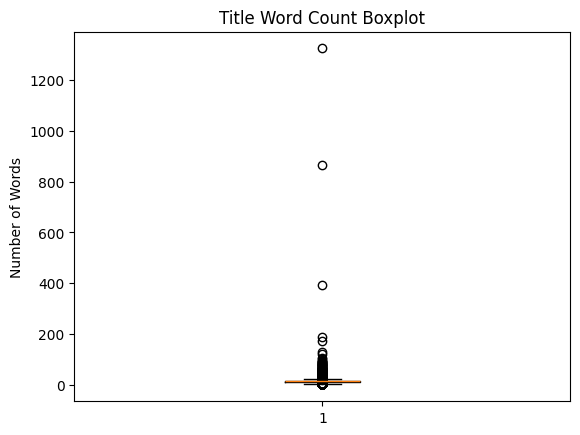

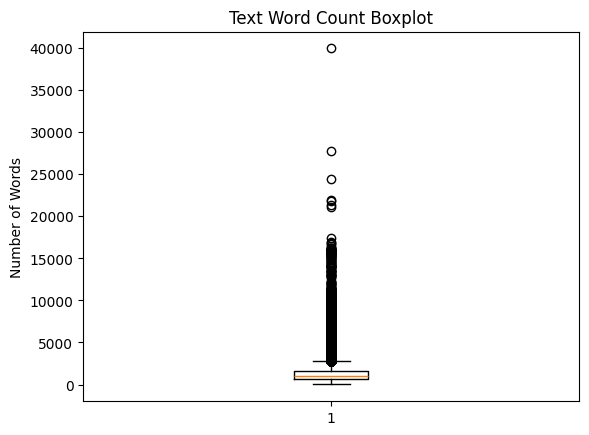

In [13]:
plt.boxplot(df_news_AI['title_word_count'], label='Title Word Count')
plt.title('Title Word Count Boxplot')
plt.ylabel('Number of Words')
plt.show()

plt.boxplot(df_news_AI['text_word_count'], label='Text Word Count')
plt.title('Text Word Count Boxplot')
plt.ylabel('Number of Words')
plt.show()

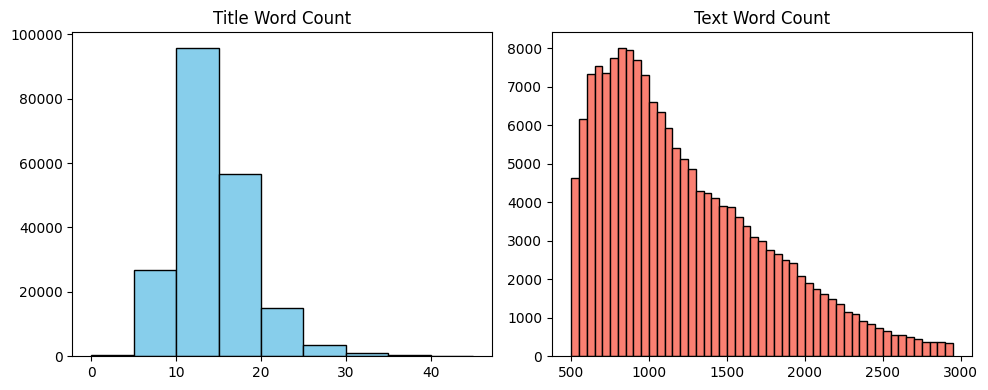

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# First subplot
ax1.hist(df_news_AI['title_word_count'], bins=range(0, 50, 5), color='skyblue', edgecolor='black')
ax1.set_title('Title Word Count')

# Second subplot
ax2.hist(df_news_AI['text_word_count'], bins=range(500, 3000, 50), color='salmon', edgecolor='black')
ax2.set_title('Text Word Count')

plt.tight_layout()
plt.show()

## 3. Clean data

### 3.1 Clean title

In [ ]:
df_news_AI.loc[15, 'url']

'https://fedtechmagazine.com/article/2025/01/4-principles-help-federal-agencies-adopt-ai-ethically-and-securely'

In [ ]:
df_news_AI['language'].value_counts()

,count
language,
en,199989


In [ ]:
# Drop the 'language' column as all the records have the same value 'en' for English
df_news_AI = df_news_AI.drop(columns=['language'])

'\n    Skip to main content\n\nBecome an Insider\nSign up today to receive premium content!\nSign Up\n\n \n\nMENU\n\n\n Log in\nMobile menu\n\nTopics\nAgencies\nFeatures\nTips & Tactics\nVideo\nCapITal\nEvents\nMore\n\nAbout Insider\nFeds in the Field \nNews\nReviews\nTelehealth\nThe Byte\nVoices\n \nSearch\n \n\nSearch\n \n\nMain menu\n\nTopics\nAgencies\nFeatures\nTips & Tactics\nVideo\nCapITal\nEvents\nMore\n\nAbout Insider\nFeds in the Field \nNews\nReviews\nTelehealth\nThe Byte\nVoices\n \nSearch\n \nEnergy & Utilities\nEnterprise\nFinancial Services\nLegal\nManufacturing\nNonprofit\nRetail\nSmall Business\nSports & Entertainment\nStartups\nTrending Now\n\nArtificial Intelligence\nCloud\nData Analytics\nData Center\nDigital Workspace\nHardware\nInternet\nManagement\nNetworking\nSecurity\nSoftware\nTrending Now\nData Center\n\n\nVertiv’s High-Performance Computing Infrastructure Enables AI\n\nSecurity\n\n\nHow HPE Helps Agencies Build Secure Server Solutions\n\nManagement\n\n\n30 Federal IT Influencers Worth a Follow in 2024\n\n30 Federal IT Influencers Worth a Follow in 2024\n\nNov 29 2024\nChief AI officers leave their mark on this year’s list of the top technologists in government to follow.\n\n \n\n\nFedTech Magazine\nCurrent Issue | Archive\ntwitter\n\n\nfeed\nHome»Security \n\n \nClose\n\nSee How Your Peers Are Moving Forward in the Cloud\nNew research from CDW can help you build on your success and take the next step.\n\n\nClick Here to Read the Report\n\n \nJan\n16\n2025\nSecurity\n4 Principles to Help Federal Agencies Adopt AI Ethically and Securely\n\nIn a white paper, SolarWinds frames the challenge in terms of privacy, accountability, transparency and simplicity.\n\nby  Tanya Candia\n\nTanya Candia is an international management expert, specializing for more than 25 years in information security strategy and communication for public- and private-sector organizations.\n\nListen\nPause\n\n\xa0\n\nFederal civilian agencies understand that artificial intelligence will be increasingly useful in streamlining and automating complex workloads. They hope to use data-driven insights to enhance decision-making and address thorny problems. The Government Accountability Office reported that 20 of 23 agencies surveyed have “about 1,200 current and planned AI cases — specific challenges or opportunities that AI may solve.”\nYet, there are significant barriers to developing and deploying AI solutions. Data silos can bury insights in a mountain of data that is difficult to analyze, so agencies need workflows that will standardize, clean and validate the data. Evolving regulatory and compliance issues make it imperative to anonymize and pseudonymize personal data before training AI models. Above all, agencies must ensure that personal data will not be breached, leaked or otherwise misused. All of this speaks to the need for trust.\nClick the banner below to begin developing a comprehensive cyber resilience strategy.\n\n\xa0\nGuiding Principles for Implementing AI\nThe issues of security, trust and ethical deployment of AI are top of mind for government agencies. An in-depth analysis by SolarWinds sheds light on how to deploy AI in ways that serve both the agency and its constituents. The company’s white paper, “Navigating the AI Revolution,” shares strategies for the ethical implementation of AI. It outlines four guiding principles, discussed here in depth, along with suggestions specifically tailored to civilian agencies.\n1. Privacy and Security\nAI systems protect privacy and security when steps are taken to ensure that data is appropriately collected, used and stored. This means fully safeguarding personal and mission-critical data. A 2023 executive order on AI directs agencies to address AI systems’ most pressing security risks, including those that could present biotechnology, cybersecurity, critical infrastructure and other national security risks. Among other issues, the executive order requires that agencies create safeguards for the ethical collection and use of citizens’ personal data for AI.\nGartner recommends that organizations adopt a comprehensive AI trust, risk and security management (TRiSM) program to help them “integrate much-needed governance upfront, and proactively ensure AI systems are compliant, fair, reliable and protect data privacy.” There are many commercially available and open-source products that can help with this, but they rely on clean, standardized, validated data that has been duly anonymized or pseudonymized.\n\n1,200\nThe number of planned AI use cases under examination by federal agencies in 2023\n\nSource: SolarWinds, “Navigating the AI Revolution,” April 2024\n\n\n2. Accountability and Fairness\nAI models need to be evaluated for fairness, and their decisions regulated. This means keeping a human in the technology loop. As Krishna Sai, senior vice president for technology and engineering at SolarWinds, explains, “Feedback and validation mechanisms should be built in so that any negative experiences are proactively captured and addressed. Regularly evaluating various AI models for fairness is essential, especially because many of these models are trained on existing data and have built-in biases.”\nSai points out that it is important to identify biases in the model and work to eliminate them. An effective way to gradually remove bias is to start with basic use cases where evaluation is simple, using feedback and validation mechanisms to record and address negative user experiences. Budget-constrained civilian agencies might struggle with resource issues but should not skimp when it comes to human oversight of AI decisions and ensuring model fairness and accountability. Sai recommends choosing tools that are built with security and accountability in mind. SolarWinds’ AI by Design framework provides guidance for integrating AI into IT management solutions.\n  Regularly evaluating various AI models for fairness is essential, especially because many of these models are trained on existing data and have built-in biases.”\n\n\nKrishna Sai\nSenior Vice President for Technology and Engineering, SolarWinds\n\n3. Transparency\nForrester defines transparency as “the perception that an AI system is leading to decisions in an open and traceable way and is making every effort to share verifiable information on how it operates.” Transparency involves providing the individuals tasked with monitoring AI with clear, comprehensive visibility into exactly how the organization uses AI, along with explanations of AI-driven decisions.\nAs with anything related to IT, a single-pane-of-glass overview of the system is critical. This ensures that there are no visibility gaps, an especially critical issue when dealing with the complex environment of networks, infrastructure, databases, third-party applications and workloads that are everywhere — on-premises and in the cloud. A solution such as SolarWinds Observability provides a full-stack view, ensuring there are no visibility gaps. The offering provides real-time monitoring, alerting, logging of alerts, auditing and reporting, giving the team both a macro and micro view. This provides the critically important ability to drill down to find out why the AI component made a specific decision.\nRELATED: AI looks backward so people can move forward.\n4. Simplicity to Build Trust\nAI experiences must build on existing behaviors to make the transition organic. This means building trust in these tools gradually, not just flipping a switch and hoping for the best. Sai recommends starting with back-end systems such as HR, with an eye to ensuring a smooth, user-friendly experience that can then be translated into public-supporting systems — especially important when dealing with mission-critical applications in civilian agencies.\nGartner VP Analyst Dean Lacheca agrees with this gradual approach: “Government organizations can accelerate GenAI adoption by focusing on use cases that predominantly impact internal resources, avoid perceived risks associated with citizen-facing services and build knowledge and skill associated with the technology.”\nInvest for Lasting Benefits\nThe guiding principles of AI development and deployment might appear to impose a burden. However, the long-term, lasting benefits far outweigh any additional work. AI-based solutions can improve decision-making and insights, and Sai has seen instances of dramatically improved response time and optimized resource management. The key is to ensure trust and mitigate risk through the four guiding principles.\n      saifulasmee chede/Getty Images\n    \n\n \nMore On\n\n            Artificial Intelligence\n            \n            Data-Driven Decisions\n            \n            Innovation\n            \n            IT Governance\n            \n            Policies\n            \n            Data protection\n            \n            Risk Assessment\n            \nRelated Articles\n\nArtificial Intelligence\n\n\nTech Trends: Federal Agencies Adopt AI Capabilities for Threat Detection\nSecurity\n\n\nShadow AI: Shining Light on a Growing Security Threat\nSecurity\n\n\nStrong Asset Management Lays the Foundation for Good Security Practices\n \n\nLatest Articles\n\n \n\n4 Principles to Help Federal Agencies Adopt AI Ethically and Securely\n \n\n \n\nTech Trends: Meetings Platforms Increasingly Enhance Value for Federal Workers\n \n\n \n\nTech Trends: Federal Agencies Adopt AI Capabilities for Threat Detection\n \n\n \n\nFederal Agencies Are Poised to Become More Agile Thanks to Cloud\n \n\n \n\n \nDigital Workspace\n\nTech Trends: Meetings Platforms Increasingly Enhance Value for Federal Workers\n\n \n\n \nArtificial Intelligence\n\nTech Trends: Federal Agencies Adopt AI Capabilities for Threat Detection\n\n \n \n\n\nAdvertisement\n \n\n\nTrending Now\n\n \n\nVertiv’s High-Performance Computing Infrastructure Enables AI\n \n\n \n\nHow HPE Helps Agencies Build Secure Server Solutions\n \n\n \n\n30 Federal IT Influencers Worth a Follow in 2024\n \n\n \n\nAre Agencies Using Their Tech Innovation Budgets Meaningfully?\n \n \n\n \nFedTech\nTechnology Solutions That Drive Business\n\n\nAbout Us\nContact Us\nPrivacy\nTerms & Conditions\n\nSite Map\n\nFedTech:\nCDW:\nVisit Some Of Our Other Technology Websites:\n\n\nBizTech\n\n\nEdTech\n\n\nStateTech\n\n\nHealthTech\nResearch Everything IT\n\nTap into practical IT advice from CDW experts\nVisit the Research Hub\nGet FedTech in your Inbox Browse Email Archives\n\nSubscribe to FedTech Magazine\nBrowse Magazine Archives\n\nFedTech:\nCDW:\nBack To Top\nCopyright © 2025 CDW LLC 200 N. Milwaukee Avenue, Vernon Hills, IL 60061Do Not Sell My Personal Information\n\n'

In [ ]:
# Print sample of title 5 sample fo titles from the dataframe
print('Sample title 1:', df_news_AI.loc[15,'title'])
print('Sample title 2:', df_news_AI.loc[7,'title'])
print('Sample title 3:', df_news_AI.loc[12,'title'])
print('Sample title 4:', df_news_AI.loc[1432,'title'])
print('Sample title 5:', df_news_AI.loc[3838,'title'])

Sample title 1: 4 Principles to Help Federal Agencies Adopt AI Ethically and Securely | FedTech Magazine
Sample title 2: Pro-AI Thinking: Enhancing Industrial Environments with Artificial Intelligence
Sample title 3: IIM Ahmedabad student writes project using ChatGPT, scores A+: Sparks debate on AI, effort and what ‘real learning’ means today - The Economic Times
Sample title 4: Orca AI Secures $72.5 Million Investment to Scale Autonomous Shipping Solutions
Sample title 5: OpenAI: OpenAI working with ex-Twitter India head to navigate AI landscape: report - The Economic Times


In [ ]:
# We are going to remove title from the text column to title the information more easily
def remove_title_from_text(row):
    title = row['title']
    text = row['text']
    # Remove the title from the text using regex
    cleaned_text = re.sub(re.escape(title), '', text, flags=re.IGNORECASE)
    return cleaned_text.strip()
# Apply the function to the dataframe
#df_news_AI['text'] = df_news_AI.apply(remove_title_from_text, axis=1)

In [ ]:
# Remove when the new source for the title using regex
#pattern = r'^(.+?)(?:\s*[|-]\s*.*)?$' # '(.*?)\s*(?:\||-)
def clean_title(title):
    '''
    Cleans the title by removing source information after " | " or " - "
    Parameters:
        title (str): The original title string
    Returns:
        str: The cleaned title string
    '''
    # Remove source after " | "
    title = re.sub(r'\s\|\s.*$', '', title)

    # Remove source after " - "
    title = re.sub(r'\s-\s.*$', '', title)

    return title.strip()

# Display of title samples before cleaning
print('Before cleaning:')
print('Sample title 1:', df_news_AI.loc[15,'title'])
print('Sample title 2:', df_news_AI.loc[7,'title'])
print('Sample title 3:', df_news_AI.loc[12,'title'])
print('Sample title 4:', df_news_AI.loc[1432,'title'])
print('Sample title 5:', df_news_AI.loc[3838,'title'])

# Call the function to clean the title column
df_news_AI["clean_title"] = df_news_AI["title"].apply(lambda row: clean_title(row))
# Unify apostrophes in the title column
df_news_AI['clean_title'] = df_news_AI['clean_title'].replace('’', "'", regex=True)
df_news_AI['clean_title'] = df_news_AI['clean_title'].replace('‘', "'", regex=True)

# Display of title samples after cleaning
print('\nAfter cleaning:')
print('Sample title 1:', df_news_AI.loc[15,'clean_title'])
print('Sample title 2:', df_news_AI.loc[7,'clean_title'])
print('Sample title 3:', df_news_AI.loc[12,'clean_title'])
print('Sample title 4:', df_news_AI.loc[1432,'clean_title'])
print('Sample title 5:', df_news_AI.loc[3838,'clean_title'])


Before cleaning:
Sample title 1: 4 Principles to Help Federal Agencies Adopt AI Ethically and Securely | FedTech Magazine
Sample title 2: Pro-AI Thinking: Enhancing Industrial Environments with Artificial Intelligence
Sample title 3: IIM Ahmedabad student writes project using ChatGPT, scores A+: Sparks debate on AI, effort and what ‘real learning’ means today - The Economic Times
Sample title 4: Orca AI Secures $72.5 Million Investment to Scale Autonomous Shipping Solutions
Sample title 5: OpenAI: OpenAI working with ex-Twitter India head to navigate AI landscape: report - The Economic Times

After cleaning:
Sample title 1: 4 Principles to Help Federal Agencies Adopt AI Ethically and Securely
Sample title 2: Pro-AI Thinking: Enhancing Industrial Environments with Artificial Intelligence
Sample title 3: IIM Ahmedabad student writes project using ChatGPT, scores A+: Sparks debate on AI, effort and what 'real learning' means today
Sample title 4: Orca AI Secures $72.5 Million Investment t

In [ ]:
# Add manual modification to a title that is not correctly with the article title
df_news_AI.loc[111391,'clean_title'] = 'Another Minneapolis software business acquired for its AI technology'

### 3.1 Clean text

In [ ]:
index = [15, 7, 12, 1432, 3838, 123, 621, 429, 42, 47324]
conta = 1
for i in index:
    print(f'Sample text {conta}:', df_news_AI.loc[i,'title'])
    print(f'Sample text {conta}:', df_news_AI.loc[i,'url'])
    print(f'Sample text {conta}:', df_news_AI.loc[i,'text'])
    conta += 1
    print('\n\n\n')

Sample text 1: 4 Principles to Help Federal Agencies Adopt AI Ethically and Securely | FedTech Magazine
Sample text 1: https://fedtechmagazine.com/article/2025/01/4-principles-help-federal-agencies-adopt-ai-ethically-and-securely
Sample text 1: 
4 Principles to Help Federal Agencies Adopt AI Ethically and Securely | FedTech Magazine
    Skip to main content

Become an Insider
Sign up today to receive premium content!
Sign Up

 

MENU


 Log in
Mobile menu

Topics
Agencies
Features
Tips & Tactics
Video
CapITal
Events
More

About Insider
Feds in the Field 
News
Reviews
Telehealth
The Byte
Voices
 
Search
 

Search
 

Main menu

Topics
Agencies
Features
Tips & Tactics
Video
CapITal
Events
More

About Insider
Feds in the Field 
News
Reviews
Telehealth
The Byte
Voices
 
Search
 
Energy & Utilities
Enterprise
Financial Services
Legal
Manufacturing
Nonprofit
Retail
Small Business
Sports & Entertainment
Startups
Trending Now

Artificial Intelligence
Cloud
Data Analytics
Data Center
Digital Wor

In [ ]:
text = '    Skip to main content \n \n     Skip to search  \n La play  '
result = re.sub(r'\s*\n\s*', '\n', text)
#result = re.sub(r'\n[^\S\r\n]+', '\n', result)
result = re.sub(r'[^\S\r\n]+', ' ', result)
result = result.strip()
print(result)

Skip to main content
Skip to search
La play


In [ ]:
# Remove extra newlines, only keep one new line (/n) space
#df_news_AI['text_clean'] = df_news_AI['text'].replace(r'\s+', ' ', regex=True)
df_news_AI['clean_text'] = df_news_AI['text'].replace(r'\s*\n\s*', '\n', regex=True)
# Remove tabs and multiple white spaces, only keep a single white space
df_news_AI['clean_text'] = df_news_AI['clean_text'].replace(r'[^\S\r\n]+', ' ', regex=True)

In [ ]:
# Unify apostrophes
df_news_AI['clean_text'] = df_news_AI['clean_text'].replace('’', "'", regex=True)
df_news_AI['clean_text'] = df_news_AI['clean_text'].replace('‘', "'", regex=True)

Remove content releated to other articles, sources, and videos

In [ ]:
def truncate_boilerplate(text):

    # Define your list of "stop" phrases (\b (word boundary) so we don't accidentally match part of a larger word)
    phrases = [
        r"\bmore stories\b",
        r"\bmore on\b",
        r"\bmore from Star Tribune\b",
        r"\brelated topics\b",
        r"\blatest shows\b",
        r"\bpost navigation\b",
        r"\brelated articles\b",
        r"\bread next\b",
        r"\bread more\b",
        r"\byou may also like\b",
        r"\bread more news\b",
        r"\bDon't miss out on ET Prime stories\b",
        r"\bget your daily dose of business updates\b",
        r'\bview comments recommended\b',
        r'\bSee all comments\b',
        r'\bsubscribe to\b',
        r'\bsubscribe for updates\b',
        r'\brecommended stories\b',
        r'\balso from this source\b'
    ]

    # Combine them into one Regex pattern with OR (|) logic
    pattern = "|".join(phrases)

    #  Split the text at the first occurrence (case-insensitive)
    cleaned_text = re.split(pattern, text, flags=re.IGNORECASE)[0]

    # 5. Return the cleaned text, stripping any trailing spaces or newlines
    return cleaned_text.strip()

# Apply the function to your existing DataFrame
# This creates a new column so you don't overwrite your original data just yet!
df_news_AI['clean_text'] = df_news_AI['clean_text'].apply(truncate_boilerplate)

In [ ]:
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'title'])
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'clean_title'])
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'url'])
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'clean_text'])
#conta += 1
#print('\n\n\n')

In [ ]:
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'title'])
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'clean_title'])
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'url'])
#print(f'Sample text {conta}:', df_news_AI.loc[111391,'clean_text_2'])
#conta += 1
#print('\n\n\n')

In [ ]:
#text = df_news_AI.loc[111391,'clean_text_2']
#split = text.split(df_news_AI.loc[111391,'clean_title'])

#print(len(split))
#print(split[0])
#print(split[1])
#print(split[2])

Remove content before the main title

In [ ]:
# Remove by default the first line that have the original title in the text, to only consider the title where it is mentioned in the text
for i in range(len(df_news_AI)):
    df_news_AI.loc[i,'clean_text'] = df_news_AI.loc[i,'clean_text'].replace(df_news_AI.loc[i,'title'], '', 1)

In [ ]:
# Clean the first part of the text by removing everything before the title
for i in df_news_AI.index:
    title = df_news_AI.loc[i,'clean_title']
    text = df_news_AI.loc[i,'clean_text']

    # Clean the inital part of the text
    # Explict uisng the title to remove unnecessary information from the text (Menu, options, etc.)
    text_split = text.split(title)
    # Select the part after the split that contain the main information, in case the article does not a title in the text, we will keep the original text

    if(len(text_split) > 1):
        # If the title is mentioned several times keep the last part mentioned, that will be the most likely the begining of the article
        main_text = text_split[len(text_split)-1]
    else:
        main_text = text_split[0]

    # Select the text part that is the longest after splitting by the title, as it is more likely to be the main content of the article,
    # Save the cleaned text back to the dataframe
    df_news_AI.loc[i,'clean_text'] = main_text

In [ ]:
index = [15, 7, 12, 1432, 3838, 123, 621, 429, 42, 47324,
        28992, 13, 154739, 74146, 111391, 140667, 184569, 13314, 158498,
        73843, 61779, 8664, 86215, 196519]
conta = 1
for i in index:
    print(f'Sample text {conta}:', df_news_AI.loc[i,'clean_title'])
    print(f'Sample text {conta}:', df_news_AI.loc[i,'url'])
    print(f'Sample text {conta}:', df_news_AI.loc[i,'clean_text'])
    conta += 1
    print('\n\n\n')

Sample text 1: 4 Principles to Help Federal Agencies Adopt AI Ethically and Securely
Sample text 1: https://fedtechmagazine.com/article/2025/01/4-principles-help-federal-agencies-adopt-ai-ethically-and-securely
Sample text 1: 
In a white paper, SolarWinds frames the challenge in terms of privacy, accountability, transparency and simplicity.
by Tanya Candia
Tanya Candia is an international management expert, specializing for more than 25 years in information security strategy and communication for public- and private-sector organizations.
Listen
Pause
Federal civilian agencies understand that artificial intelligence will be increasingly useful in streamlining and automating complex workloads. They hope to use data-driven insights to enhance decision-making and address thorny problems. The Government Accountability Office reported that 20 of 23 agencies surveyed have “about 1,200 current and planned AI cases — specific challenges or opportunities that AI may solve.”
Yet, there are signif

In [ ]:
# Check the number of words in the title column
df_news_AI['title_word_clean_count'] = df_news_AI['clean_title'].apply(lambda x: len(x.split()))
df_news_AI['text_word_clean_count'] = df_news_AI['clean_text'].apply(lambda x: len(x.split()))


print('Average number of words in the title:', df_news_AI['title_word_clean_count'].mean())
print('Average number of words in the text:', df_news_AI['text_word_clean_count'].mean())

Average number of words in the title: 11.702338628624574
Average number of words in the text: 757.0671786948283


In [ ]:
#df_news_AI[df_news_AI['text_word_count_clean']>1500].sample(10)

## 4. Filter articles

In [ ]:
# Join title and text columns and do count number of words
df_news_AI['title_text_clean'] = df_news_AI['clean_title'] + ' ' + df_news_AI['clean_text']
df_news_AI['title_text_clean_count'] = df_news_AI['title_text_clean'].apply(lambda x: len(x.split()))

In [ ]:
print('Describe title word count:')
print(df_news_AI['title_word_clean_count'].describe())

print('Describe text word count:')
print(df_news_AI['text_word_clean_count'].describe())

print('Describe text word count:')
print(df_news_AI['title_text_clean_count'].describe())

Describe title word count:
count    199989.000000
mean         11.702339
std           5.076872
min           1.000000
25%           9.000000
50%          11.000000
75%          14.000000
max         861.000000
Name: title_word_clean_count, dtype: float64
Describe text word count:
count    199989.000000
mean        757.067179
std         792.681166
min           0.000000
25%         319.000000
50%         618.000000
75%         967.000000
max       27718.000000
Name: text_word_clean_count, dtype: float64
Describe text word count:
count    199989.000000
mean        768.769517
std         793.298520
min           1.000000
25%         331.000000
50%         631.000000
75%         980.000000
max       27739.000000
Name: title_text_clean_count, dtype: float64


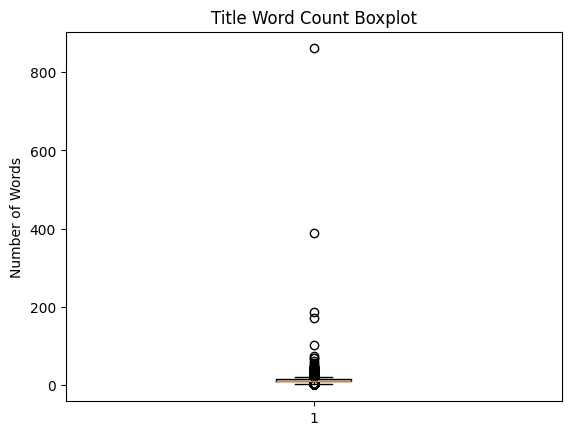

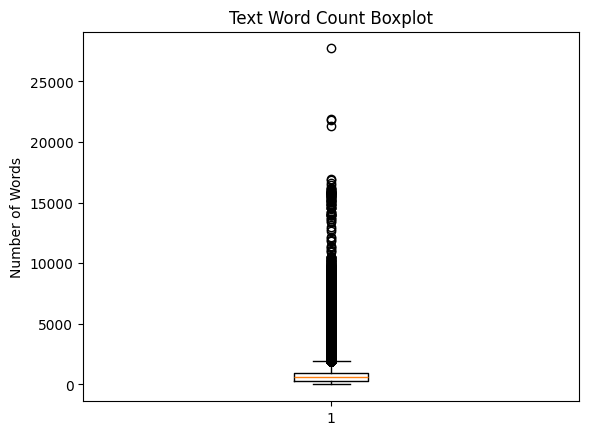

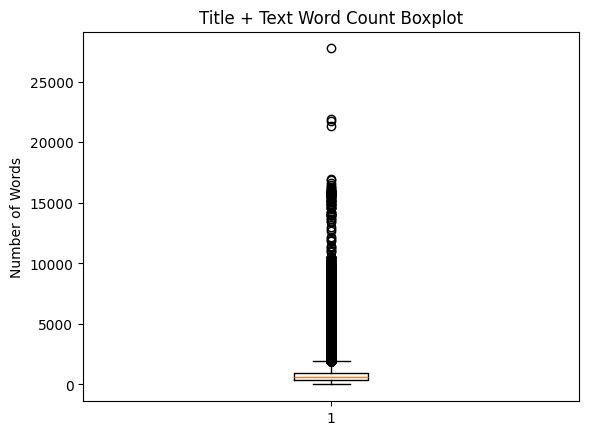

In [ ]:
plt.boxplot(df_news_AI['title_word_clean_count'], label='Title Word Count')
plt.title('Title Word Count Boxplot')
plt.ylabel('Number of Words')
plt.show()

plt.boxplot(df_news_AI['text_word_clean_count'], label='Text Word Count')
plt.title('Text Word Count Boxplot')
plt.ylabel('Number of Words')
plt.show()

plt.boxplot(df_news_AI['title_text_clean_count'], label='Title + Text Word Count')
plt.title('Title + Text Word Count Boxplot')
plt.ylabel('Number of Words')
plt.show()

In [ ]:
df_aux = df_news_AI[df_news_AI['title_text_clean_count'] >= 50]
print(df_aux['title_text_clean_count'].describe())

count    186029.000000
mean        824.384693
std         795.128662
min          50.000000
25%         411.000000
50%         672.000000
75%        1016.000000
max       27739.000000
Name: title_text_clean_count, dtype: float64


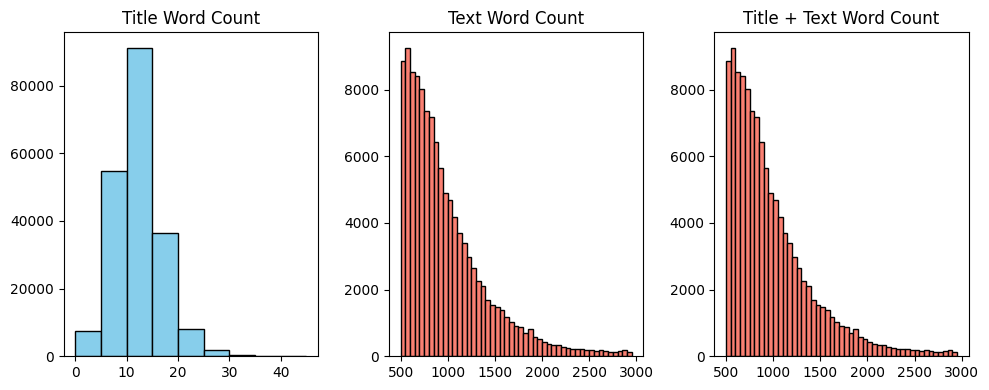

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

# First subplot
ax1.hist(df_news_AI['title_word_clean_count'], bins=range(0, 50, 5), color='skyblue', edgecolor='black')
ax1.set_title('Title Word Count')

# Second subplot
ax2.hist(df_news_AI['text_word_clean_count'], bins=range(500, 3000, 50), color='salmon', edgecolor='black')
ax2.set_title('Text Word Count')

# Third subplot
ax3.hist(df_news_AI['text_word_clean_count'], bins=range(500, 3000, 50), color='salmon', edgecolor='black')
ax3.set_title('Title + Text Word Count')

plt.tight_layout()
plt.show()

In [ ]:
# Imagane url not revant
df_news_AI.loc[2227,'url']

'https://www.rawpixel.com/image/12203262/photo-image-plant-living-room-wooden'

In [ ]:
df_news_AI[df_news_AI['title_text_clean_count']==150].head(3)

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count
2823,https://www.freepressjournal.in/ampstories/lif...,2023-06-01,Elon Musk as a DESI groom? Artist generates AI...,\n\nElon Musk as a DESI groom? Artist generate...,2023,6,166,16,Elon Musk as a DESI groom? Artist generates AI...,"\nBy: FPJ Web Desk | June 01, 2023\nElon Musk,...",16,134,Elon Musk as a DESI groom? Artist generates AI...,150
4360,https://www.hindustantimes.com/business/openai...,2024-07-31,OpenAI starts roll-out of advanced voice mode ...,\n\n \n\nOpenAI starts roll-out of advanced vo...,2024,7,1467,16,OpenAI starts roll-out of advanced voice mode ...,"Reuters | Jul 31, 2024 08:34 AM IST Read this...",13,137,OpenAI starts roll-out of advanced voice mode ...,150
5415,https://www.fiercepharma.com/marketing/amgen-l...,2022-07-08,"Amgen showcases its scientists, AI advances in...","\nAmgen showcases its scientists, AI advances ...",2022,7,150,9,"Amgen showcases its scientists, AI advances in...",\nFierce Pharma\nFierce Biotech\nFierce Health...,9,141,"Amgen showcases its scientists, AI advances in...",150


In [ ]:
original_rows = df_news_AI.shape[0]
# Filter out articles with text word count less than 50 with less than 50 words
df_news_AI = df_news_AI[df_news_AI['title_text_clean_count'] >= 50]
filtered_rows_1 = df_news_AI.shape[0]
print('Number of rows before filtering:', original_rows)
print('Number of rows after filtering:', filtered_rows_1)
print('Number of rows removed {} , which represents {:.2%}'.format(original_rows - filtered_rows_1, (original_rows - filtered_rows_1) / original_rows))

Number of rows before filtering: 199989
Number of rows after filtering: 186029
Number of rows removed 13960 , which represents 6.98%


In [ ]:
# Reset index in the dataframe
#df_news_AI.reset_index(drop=True, inplace=True)

In [ ]:
display(df_news_AI.head())

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,2023,11,596,16,The Road Ahead: How China's AI Foundation Mode...,\nIr ao contidoVen. 10 de novembro de 2023 Vid...,16,580,The Road Ahead: How China's AI Foundation Mode...,596
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,2023,11,622,10,Microsoft and Nvidia to Empower Developers wit...,"\nByМамфо Брешиа\nҚараша 15, 2023\nMicrosoft a...",10,587,Microsoft and Nvidia to Empower Developers wit...,597


In [ ]:
df_news_AI.sample(10)['title']

,title
191812,Eviden announces JARVICE AI Platform Software ...
64555,Celestica: The AI Stock Set For High Growth Af...
154217,\r \tNvidia to mass produce AI supercomputers ...
7662,Ferret AI (FERRET) Price Prediction & Price Fo...
79808,"US Stocks See Uncertainty Ahead of Key Data, ..."
180807,Stealth Writer AI | Ultimate Review For 2024 -...
3172,Astro Bot: All Bot Locations in Machine Learning
13709,Enabling innovation: Gen AI for the clean core...
66787,Video Advertising Pioneer Waymark Rolls Out AI...
152359,ANA's Global CMO Growth Council Releases First...


Apply embeddings and cosine similarity to filter articles not relevant to AI in companies

In [ ]:
# Load embeddings for the text and title columns using a pre-trained model (e.g., BERT, GloVe, etc.)
model_embeddings = SentenceTransformer('all-MiniLM-L6-v2')

# Create the reference topics to filter text
reference_topics = [
    "AI protections and regulations for companies",
    "The role of Prompt Engineering",
    "Industy applications of artificial intelligence",
    "Use of machine learning in business operations and corporate strategy",
    "The impact of AI on the workforce and job market",
    "The future of AI in the corporate world",
    "Artificial intelligence improving productivity in organizations",
    "Digital transformation driven by AI in companies",
    "initial generative AI experience",
    "The artificial intelligence chatbots in the workplace",
    "jobs most under threat from AI, robots and big data",
    "NextGen AI adoption"
]

# Generate embeddings for the reference topics
reference_embeddings = model_embeddings.encode(reference_topics, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df_news_AI.head()

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",2025,6,483,14,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Open menuBrandsnewsletterspodcastseventsroundt...,12,470,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",482
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,2024,7,812,15,This AI video of gymnastics might be the freak...,"\nJennifer Sandlin\n5:13 am Mon\nJul 1, 2024\n...",12,724,This AI video of gymnastics might be the freak...,736
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",2024,9,884,12,"If using AI feels like a chore, try this","\nBoing Boing's Shop\n8:00 am Wed\nSep 18, 202...",9,802,"If using AI feels like a chore, try this \nBoi...",811
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,2023,11,596,16,The Road Ahead: How China's AI Foundation Mode...,\nIr ao contidoVen. 10 de novembro de 2023 Vid...,16,580,The Road Ahead: How China's AI Foundation Mode...,596
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,2023,11,622,10,Microsoft and Nvidia to Empower Developers wit...,"\nByМамфо Брешиа\nҚараша 15, 2023\nMicrosoft a...",10,587,Microsoft and Nvidia to Empower Developers wit...,597


In [ ]:
conta = 1
for i in [0,1,4]:
  print('Sample', i)
  print(df_news_AI.loc[i,'url'])
  print(df_news_AI.loc[i,'title_text_clean'][0:500])
  conta = conta + 1

Sample 0
https://blockworks.co/price/bad
Bad Idea AI Price (BAD), Market Cap, Price Today & Chart History Open menuBrandsnewsletterspodcastseventsroundtablestoken transparencyetf trackerpricesresearchanalyticshomepricesBad Idea AI price (BAD)Bad Idea AIBADLive Bad Idea AI price updates and the latest Bad Idea AI news.pricesponsored byBlockworks Research$0.0000000112$0(0%)24h low$0.0000000124h high$0.00000001PriceMarket Cap1D7D1M3M1YYTDALLVSUSDUSDBTCBTC TradingView ChartLinearLogarithmicThe live Bad Idea AI price today is $0.00000001 wi
Sample 1
https://boingboing.net/2024/07/01/this-ai-video-of-gymnastics-might-be-the-freakiest-ive-seen-yet.html
This AI video of gymnastics might be the freakiest I've seen yet 
Jennifer Sandlin
5:13 am Mon
Jul 1, 2024
Screenshot: Luma AI
I'm sure by now you're tired of looking at terrible or terribly weird AI art, but bear with me. This AI video of gymnasts in action is truly one of the strangest creations of AI art I've seen to date. I'm ashamed to adm

Microsoft and Nvidia are joining forces to provide developers with the tools they need to run and customize AI models on Windows PCs. At the Microsoft Ignite event, Microsoft unveiled Windows AI Studio, a centralized hub where developers can access a range of AI models and tailor them to their specific requirements.Windows AI Studio builds upon the existing Azure AI Studio and integrates with other services like Hugging Face, offering developers a comprehensive solution. It features an intuitive user interface with guided workspace setup, allowing developers to fine-tune small language models (SLMs) like Microsoft's Phi, Meta's Llama 2, and Mistral.The power of Windows AI Studio extends beyond configuration. It provides developers with the ability to test the performance of their models using Prompt Flow and Gradio templates. Microsoft plans to release Windows AI Studio as a Visual Studio Code extension in the near future, making it easily accessible to developers.Simultaneously, Nvidia announced updates to TensorRT-LLM, a tool initially designed to enhance the efficiency of running large language models (LLMs) on H100 GPUs. The latest update enables TensorRT-LLM to work seamlessly with GeForce RTX 30 and 40 Series GPUs, equipped with 8GB of RAM or more.Furthermore, Nvidia is working on making TensorRT-LLM compatible with OpenAI's Chat API through a new wrapper. This compatibility allows developers to run LLMs directly on their PCs, addressing concerns about data privacy in the cloud. The upcoming TensorRT-LLM 6.0 release promises up to five times faster inference and support for the new Mistral 7B and Nemotron-3 8B models.Both Microsoft and Nvidia are striving to create a “hybrid loop” development pattern, enabling AI development across both cloud and local devices. Developers can now leverage Microsoft's powerful cloud servers to alleviate the computational load on their devices, expanding their capabilities and accelerating the pace of AI innovation.Жиі қойылатын сұрақтар (FAQ)What is Windows AI Studio?Windows AI Studio is a unified platform developed by Microsoft that allows developers to access and customize AI models. It offers a user-friendly interface and tools to fine-tune small language models, such as Microsoft's Phi, Meta's Llama 2, and Mistral.What functionality does Windows AI Studio provide?Windows AI Studio enables developers to test the performance of their models using Prompt Flow and Gradio templates. It also integrates with Azure AI Studio and other services like Hugging Face, providing a comprehensive solution for AI development.How can developers access Windows AI Studio?Microsoft plans to release Windows AI Studio as a Visual Studio Code extension in the near future, making it easily accessible to developers directly from their development environment.What is TensorRT-LLM?TensorRT-LLM is a tool developed by Nvidia that optimize

In [ ]:
# Transfrom title_text_clean into a list an consider
# 256-token capacity of the model that is around 1200 characters which is 200-250 words
texts_to_score = df_news_AI['clean_text'].str[0:1200].tolist()

In [ ]:
# Generate tile+text embeddings for the text column
# Only consider top frist 500 tokens (Generate tile+text embeddings for the text column Only consider top frist 500 tokens)
# Start the pool (this spins up multiple background workers)
pool = model_embeddings.start_multi_process_pool() # model_embbedings
text_embeddings = model_embeddings.encode(
    texts_to_score,
    pool=pool,
    batch_size=128,
    show_progress_bar=True)

Chunks:   0%|          | 0/38 [00:00<?, ?it/s]

In [ ]:
print('Shape dataframe:', df_news_AI.shape)
print('Shape of reference topic embeddings:', reference_embeddings.shape)
print('Shape of text embeddings:', text_embeddings.shape)
text_embeddings.shape

Shape dataframe: (186029, 15)
Shape of reference topic embeddings: (11, 384)
Shape of text embeddings: (186029, 384)


(186029, 384)

In [ ]:
# Calculate Cosine Similarity between text embeddings and reference topic embeddings
similarities = cosine_similarity(text_embeddings, reference_embeddings)
# Extract the highest similarity score for each article across all references
similarities = similarities.max(axis=1)
# Add the similarity scores to the dataframe
df_news_AI['semantic_score'] = similarities

/tmp/ipykernel_15268/1917438282.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news_AI['semantic_score'] = similarities


count    186029.000000
mean          0.344284
std           0.133949
min          -0.035780
25%           0.245737
50%           0.350980
75%           0.444439
max           0.782119
Name: semantic_score, dtype: float64


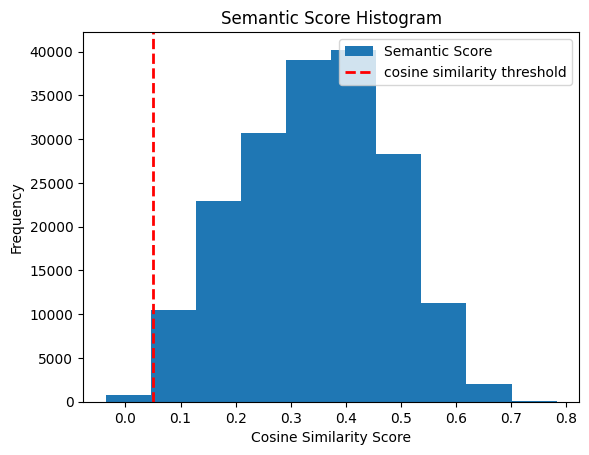

In [ ]:
print(df_news_AI['semantic_score'].describe())
plt.hist(df_news_AI['semantic_score'], label='Semantic Score')
plt.title('Semantic Score Histogram')
plt.ylabel('Frequency')
plt.xlabel('Cosine Similarity Score')
plt.axvline(x=0.05, color='red', linestyle='dashed', linewidth=2, label='cosine similarity threshold')
plt.legend()
plt.show()

In [ ]:
df_news_AI[(df_news_AI['semantic_score']>0.03) & (df_news_AI['semantic_score']<0.04)].sample(10)

,url,date,title,text,year,month,text_word_count,title_word_count,clean_title,clean_text,title_word_clean_count,text_word_clean_count,title_text_clean,title_text_clean_count,semantic_score
125254,https://www.dailymail.co.uk/news/article-13948...,2024-10-11,Trojan horse fear as MoD uses American firm's ...,Trojan horse fear as MoD uses American firm's ...,2024,10,6178,18,Trojan horse fear as MoD uses American firm's ...,\ne-mail\nAdd comment\nBing\nSite\nWeb\nEnter ...,14,4943,Trojan horse fear as MoD uses American firm's ...,4957,0.031101
58433,https://www.shortlist.com/tech/oakley-meta-sma...,2025-06-23,Oakley Meta smart glasses arrive to give fitne...,\n\nOakley Meta smart glasses arrive to give f...,2025,6,820,14,Oakley Meta smart glasses arrive to give fitne...,\nBetter-looking than the Ray-Ban Meta Wayfare...,12,663,Oakley Meta smart glasses arrive to give fitne...,675,0.039564
61504,https://www.surreynowleader.com/community/chan...,2022-05-09,Channeling the power of AI to improve hearing ...,\nChanneling the power of AI to improve hearin...,2022,5,1468,11,Channeling the power of AI to improve hearing ...,\nSearchHome\nNewsletters\nSubscribe\nSubscrib...,11,1457,Channeling the power of AI to improve hearing ...,1468,0.035604
38096,https://www.cbssports.com/nfl/news/nfl-week-13...,2025-11-30,"Week 13 NFL picks, score predictions, best bet...","\n\nWeek 13 NFL picks, score predictions, best...",2025,11,1559,15,"Week 13 NFL picks, score predictions, best bet...",\nsite: media | arena: nfl | pageType: stories...,12,1544,"Week 13 NFL picks, score predictions, best bet...",1556,0.039228
48,https://wsvn.com/sports/ap-source-flyers-trade...,2022-03-20,AP source: Flyers trade captain Claude Giroux ...,\n\nAP source: Flyers trade captain Claude Gir...,2022,3,970,20,AP source: Flyers trade captain Claude Giroux ...,"\nSkip to content\nWSVN 7News | Miami News, We...",12,950,AP source: Flyers trade captain Claude Giroux ...,962,0.036077
89718,https://www.gillettenewsrecord.com/obituaries/...,2023-01-26,Jerry Claude Shuck | Obituaries | gillettenews...,\nJerry Claude Shuck | Obituaries | gillettene...,2023,1,1623,7,Jerry Claude Shuck,", 78, died Monday, Jan. 23, 2023, surrounded b...",3,1410,"Jerry Claude Shuck , 78, died Monday, Jan. 23,...",1413,0.038353
132750,https://www.the-express.com/entertainment/cele...,2024-05-07,Katy Perry confirms reason she skipped Met Gal...,Katy Perry confirms reason she skipped Me...,2024,5,1158,21,Katy Perry confirms reason she skipped Met Gal...,\nExpress. Home of the Daily and Sunday Expres...,12,244,Katy Perry confirms reason she skipped Met Gal...,256,0.036893
80056,https://citylife.capetown/sm/science/what-woul...,2023-10-14,Fa'ata'ita'iina o Gaoioiga Vulu i luga o Exopl...,Fa'ata'ita'iina o Gaoioiga Vulu i luga o Exop...,2023,10,674,17,Fa'ata'ita'iina o Gaoioiga Vulu i luga o Exopl...,"\nByVicky Stavropoulou\nOketopa 12, 2023\nA ne...",17,621,Fa'ata'ita'iina o Gaoioiga Vulu i luga o Exopl...,638,0.036717
174307,https://www.nationalworld.com/whats-on/arts-an...,2025-09-17,Foo Fighters tease potential tour with AI vide...,\n\nFoo Fighters tease potential tour with AI ...,2025,9,1026,13,Foo Fighters tease potential tour with AI vide...,\nAll Sections\nSign InSubscribe\nRobert Redfo...,13,1013,Foo Fighters tease potential tour with AI vide...,1026,0.038029
39919,https://www.mexc.co/en-IN/price/PALMAI/CUP,2025-12-10,PALMAI to CUP: Convert PaLM AI to Cuban Peso |...,PALMAI to CUP: Convert PaLM AI to Cuban Peso |...,2025,12,4093,17,PALMAI to CUP: Convert PaLM AI to Cuban Peso,ExchangeDEX+Buy CryptoMarketsSpotFutures500XEa...,9,4077,PALMAI to CUP: Convert PaLM AI to Cuban Peso E...,4086,0.035978


In [ ]:
# Index colmuns with cases that don't make sense: 108750

# Case 1: index 108750,
# title: This 22-year-old is trying to save us from ChatGPT before it changes writing forever
# url: https://www.klcc.org/npr-politics/npr-politics/2023-01-17/this-22-year-old-is-trying-to-save-us-from-chatgpt-before-it-changes-writing-forever

# Case 2: index 11560
# title: Native Stew
# url: http://www.nativestew.com/2025/03/sailboat-borealis-phone-wallpaper.html

# Case 3: index 101074
# title: Native Stew
# url: http://www.nativestew.com/2024/10/junkanoo-sailboat.html

# Case 4: index 64628
# title: LG UQ8000 Series 86” 4K LED Smart TV w/ ThinQ AI
# url: https://www.lg.com/ca_en/backups/tvs-soundbars/smart-tvs/86uq8000aub/


# 125254 (ok),

df_news_AI.loc[58433,'url']

'https://www.shortlist.com/tech/oakley-meta-smart-glasses-arrive-to-give-fitness-fans-some-ai-goodness'

In [ ]:
df_news_AI.loc[58433,'clean_title']

'Oakley Meta smart glasses arrive to give fitness fans some AI goodness'

In [ ]:
df_news_AI.loc[58433,'clean_text']

"\nBetter-looking than the Ray-Ban Meta Wayfarer?\nComments\n( 0 )\n()\nWhen you purchase through links on our site, we may earn an affiliate commission. Here's how it works.\n(Image credit: Meta)\nBy\nAndrew Williams\npublished\n23 June 2025\nin News\nThe Ray-Ban Meta collab gave us the most successful pair of smart glasses to date, and now Meta has jumped in bed with Oakley for a fresh pair, the Oakley Meta HSTN.Before you start thinking this is the result of a falling out between Meta and Ray-Ban: both Oakley and Meta are brands owned by EssilorLuxottica, so it really isn't.But back to the important stuff. The new Oakley Meta HSTN smart glasses are meant to be pronounced “how stuhn” and will cost $499 when they go up for pre-order on July 11. We don't have specific UK pricing but we have heard they will be available here.As well as a fresh look, the Oakley Meta HSTN bring some major hardware upgrades. They can capture 3K video, where the Ray-Ban Meta glasses are limited to 1080p. Th


Skip to content
WSVN 7News | Miami News, Weather, Sports | Fort Lauderdale
News
Local
Miami-Dade
Broward
Florida
Trending
US & World
Politics
Help Me Howard
Hope and Healing
Investigations
Special Reports
7 Spotlight
Weather
Forecast
Interactive Radar
Video Forecast
Watches and Warnings
Forecast Models
Forecast Cone
Hurricane Tips
7Weather App
Hurricane Tracker App
Surviving a Storm
Sports
All Sports
Miami Dolphins
Miami Heat
Miami Marlins
Florida Panthers
Miami Hurricanes
Florida Gators
Florida State Seminoles
Entertainment
Entertainment
Belkys' Bite Blog
Bite with Belkys
Deco Drive
Shireen's Favorite Things
…
Employment Opportunities
TV Listings
7News Team
Watch 7News Live
Links Mentioned On Air
65 years of Channel 7
Live
Search
AP source: Flyers trade captain Claude Giroux to Panthers
By Associated Press
March 19, 2022
Share
PHILADELPHIA (AP) — Claude Giroux will try to win his first Stanley Cup in Florida.The Philadelphia Flyers have traded Giroux after he played his 1,000th career game with the franchise to the Florida Panthers, a person familiar with the deal told The Associated Press.The person spoke to the AP on condition of anonymity Saturday because the trade had not been announced.The move strengthens Florida's status as a Stanley Cup contender, giving Aleksander Barkov an elite linemate and one of the best faceoff aces in the NHL. The Panthers earlier in the week traded a first-round pick and more for Montreal defenseman Ben Chiarot.
Giroux was traded after he played his 1,000th game with the Flyers and was feted Thursday with a game in his honor. Drafted in the first round in 2006, Giroux made his Philadelphia debut on Feb. 19, 2008, and has played his entire career with the Flyers. He has 900 career points and is eighth on the Flyers' career list with 291 goals. He helped the Flyers reach the 2010 Stanley Cup finals and was awarded the All-Star MVP this season.The Flyers also acquired forward Owen Tippett and draft picks.Giroux had to waive his no-movement clause that was part of his $66.2 million, eight-year contract.He joined Hall of Famer and two-time Stanley Cup champion Bobby Clarke as the only players to reach 1,000 games entirely with the Flyers. Giroux was named captain on Jan. 15, 2013.The Flyers have only 19 wins and are tied for last place in the Metropolitan Division.It's the second significant trade for Florida as the deadline nears, coming after the Panthers landed Chiarot.The defenseman is expected to join Florida this coming week, when the Panthers play in Montreal. That will likely also be Giroux's debut game with his new club.It's yet another clear sign Florida is all-in on finally reversing its fortunes. The Panthers went to the Stanley Cup final in 1996, the franchise's third season.They haven't won a playoff series since, cycling through more than a dozen coaches, going from one rebuild to another, often playing before an empty arena and dogged by rumors for years that they would be leaving Florida.But this is as good as it has ever been for the Panthers, who have the second-best record in the NHL entering Saturday, have a Hart Trophy contender in Jonathan Huberdeau, a half-dozen 20-goal scorers this season already and an elite player in Barkov locked up for seven more years.Plus, the Panthers have survived a ton of adversity this season.The team watched Joel Quenneville step down as coach seven unbeaten games into the season as part of the fallout from the Chicago Blackhawks' scandal involving an abused player — something that happened when Quenneville coached there more than a decade ago. And on Friday, the team watched as top defenseman Aaron Ekblad crawled to the bench in agony after enduring a lower-leg injury in Anaheim. But by night's end the team already had enough information to believe Ekblad dodged the sort of significant injury that likely would have ended his season and put a huge dent in Florida's title hopes.The Flyers have long been out of championship contention. But Giroux's 1,000th game was a rare occasion to celebrate in Philadelphia. Clarke presented Giroux with the silver stick to mark the occasion, and he was given a Rolex watch by his teammates and a crystal by the NHL. Giroux also has played in 85 career playoff games for Philadelphia.“The fans and the organization, my teammates have been so good to me for so many years and that's one of the reasons it was pretty emotional after the game,” Giroux said.
Copyright 2021 The Associated Press. All rights reserved. This material may not be published, broadcast, rewritten or redistributed.
Join our Newsletter for the latest news right to your inbox
Email address
Submit
Trending
2 dead, 2 hospitalized, 1 arrested after shooting on transit bus in Fort Lauderdale; 3 others hurt in related crash
Witnesses: employee at NW Miami-Dade Burger King shoots up car driving by outside
Man fatally shot on Palmetto Expressway in Hialeah was rapper Baby Cino; surviving victim released from hospital
Mayor Daniella Levine Cava signs new law requiring landlords to give tenants 60-day notice of rent increase, eviction
More Trending Stories
WSVN-TVSunbeam Television Corp
1401 79th Street Causeway
Miami, FL 33141
Switchboard: (305) 751-6692
Newsroom: (305) 795-2777
Join us
PRIVACY POLICY
TERMS OF SERVICES
TV LISTINGS
CONTACT US
INTERNSHIPS
EMPLOYMENT OPPORTUNITIES
ADVERTISE WITH US
WSVN FCC PUBLIC FILE
EEO PUBLIC FILE REPORT
CHILDRENS PROGRAMMING
ED ANSIN
All content © Copyright 2000 - 2022 WSVN-TV. WSVN broadcast educational and informational programming for children, and file quarterly reports with the FCC detailing the station's outreach to children. The public may view the reports by going to WSVN.com and clicking on "FCC Public File", or by visiting the FCC's website at FCC.org. For more information on this site, please read our Privacy Policy, and Terms of Service.

In [ ]:
# Filter out articles based on cosine similarity score, for example, keep articles with a score above 0.05
df_news_AI_2 = df_news_AI[df_news_AI['semantic_score'] > 0.00002]
filtered_rows_2 = df_news_AI_2.shape[0]
print('Number of rows before filtering:', original_rows)
print('Number of rows after filtering:', filtered_rows_2)
print('Number of rows removed {} , which represents {:.2%}'.format(original_rows - filtered_rows_2, (original_rows - filtered_rows_2) / original_rows))

Number of rows before filtering: 199989
Number of rows after filtering: 185960
Number of rows removed 14029 , which represents 7.01%


In [ ]:
# Total filter rows
#df_news_AI = df_news_AI[df_news_AI['semantic_score'] > 0.05]
#filtered_rows_total = (original_rows - filtered_rows_1) + (original_rows-filtered_rows_2)
#print('Number of rows before filtering:', original_rows)
#print('Number of rows after filtering:', df_news_AI.shape[0])
#print('Number of rows removed {} , which represents {:.2%}'.format(filtered_rows_total, (filtered_rows_total) / original_rows))

In [ ]:
# Filter the index in the dataframe
df_news_AI.reset_index(drop=True, inplace=True)

In [ ]:
df_news_AI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186029 entries, 0 to 186028
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   url                     186029 non-null  object        
 1   date                    186029 non-null  datetime64[ns]
 2   title                   186029 non-null  object        
 3   text                    186029 non-null  object        
 4   year                    186029 non-null  int32         
 5   month                   186029 non-null  int32         
 6   text_word_count         186029 non-null  int64         
 7   title_word_count        186029 non-null  int64         
 8   clean_title             186029 non-null  object        
 9   clean_text              186029 non-null  object        
 10  title_word_clean_count  186029 non-null  int64         
 11  text_word_clean_count   186029 non-null  int64         
 12  title_text_clean        186029

In [ ]:
# Export data
df_news_AI.to_parquet('/content/drive/MyDrive/Colab Notebooks/Final Project NLP/df_news_clean.parquet')